In [1]:
pip install pandas rdflib networkx owlready2 owlrl numpy pykeen seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 47.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.6 MB/s eta 0:00:00
  Created wheel for owlready2: filename=owlready2-0.50-cp312-cp312-linux_x86_64.whl size=24567081 sha256=339afbecc05bbd5f4ff16c04b4eea371aa0a3265121dd77284f2525c87e5cc2e
  Stored in directory: /root/.cache/pip/wheels/fb/9d/9d/2

In [2]:
import pandas as pd
import rdflib
from rdflib import Literal
from rdflib.namespace import DC, FOAF

import networkx as nx
from owlready2 import *

from owlrl import DeductiveClosure, OWLRL_Semantics

In [5]:
#load the ontology
HIonto = rdflib.Graph()
HIonto.parse('/content/Modolled_Individuals_Assigment.ttl', format='turtle')


<Graph identifier=Nbeb0f44860704102ae36bcdd2aaa45e2 (<class 'rdflib.graph.Graph'>)>

In [6]:
#BASIC MEASURES

#1. number of classes
classes = list(HIonto.query(
    """PREFIX owl: <http://www.w3.org/2002/07/owl#>
    SELECT DISTINCT ?s
    WHERE {?s rdf:type owl:Class.
    FILTER isURI(?s)
    }
    """
))

print(f'Number of classes are: {len(classes)}')
#2. number of properties
Obj_properties = list(HIonto.query(
    """PREFIX owl:<http://www.w3.org/2002/07/owl#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    SELECT DISTINCT ?s
    WHERE {?s rdf:type owl:ObjectProperty.
    FILTER isURI(?s)
    }
    """
))

Data_propeties = list(HIonto.query(
    """PREFIX owl:<http://www.w3.org/2002/07/owl#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    SELECT DISTINCT ?s
    WHERE {?s rdf:type owl:DatatypeProperty.
    FILTER isURI(?s)
    }
    """
))
print(f'Total properties are: {len(Obj_properties)+len(Data_propeties)}, object: {len(Obj_properties)}, datatype: {len(Data_propeties)}')

#3. number of triples
triples_number = list(HIonto.query(
    """PREFIX owl:<http://www.w3.org/2002/07/owl#>
    SELECT (COUNT(*) AS ?count)
    WHERE {?s ?p ?o.
    FILTER isURI(?s)}
    """
))

print(f'Number of triples are: {int(triples_number[0][0])}')

#4. Number of entities (classes + individuals)
entities = list(HIonto.query(
    """PREFIX owl:<http://www.w3.org/2002/07/owl#>
    SELECT DISTINCT ?s
    WHERE {?s ?p ?o.
    FILTER isURI(?s)}
    """
))
print(f'Number of entities are: {len(entities)}')

#5. number of individuals
individuals = list(HIonto.query(
    """PREFIX owl:<http://www.w3.org/2002/07/owl#>
    SELECT DISTINCT ?ind
    WHERE {?ind a owl:NamedIndividual .
    FILTER isURI(?ind)}
    """

))

print(f'Number of individuals are: {len(individuals)}')

#6. number of inferences
#run a reasoner
pre_inference = rdflib.Graph()
pre_inference.parse('/content/Modolled_Individuals_Assigment.ttl')
DeductiveClosure(OWLRL_Semantics).expand(pre_inference)
inferences = pre_inference - HIonto
print(f'Number of inferences are: {len(inferences)}')




Number of classes are: 107
Total properties are: 88, object: 82, datatype: 6
Number of triples are: 2229
Number of entities are: 547
Number of individuals are: 339
Number of inferences are: 4388


In [7]:
#NETWORKX measurments
from rdflib.extras.external_graph_libs import rdflib_to_networkx_multidigraph
from rdflib import Graph, RDF, RDFS, OWL, URIRef, Literal, BNode

nx_HIgraph = rdflib_to_networkx_multidigraph(HIonto)
print(f'Nodes: {nx_HIgraph.number_of_nodes()}')
print(f'Edges: {nx_HIgraph.number_of_edges()}')

density = nx.density(nx_HIgraph)
print(f'Density: {density}')

Nodes: 1175
Edges: 2336
Density: 0.0016934285403602885


In [8]:
#LINK PREDICTION TASK
import numpy as np
import pykeen
import sys
import pathlib
import os

from pykeen import triples

INFO:pykeen.utils:Using opt_einsum


In [9]:
#load merged onolotgy for link predicton
MERGED_onto = Graph()
MERGED_onto.parse('/content/hi-ontology-populated.ttl')

#1. extract triples
#first need to identify wehre to split to get names
#function strips the name of entity from the uri
def split_name (uri):
  uri = str(uri)
  if '#' in uri:
    name = uri.split('#')[1]
  else:
    name = uri.split('/')[-1]
  return name

triples_list = [
    (split_name(s), split_name(p), split_name(o) )
    for s, p, o in MERGED_onto.triples((None, None, None))
    if str(s).startswith('https://w3id.org/hi-ontology#') #need to make sure only get HI ontolgy subject, object to onyl egt relenavt triples (no annotations, or external links)
    and str(o).startswith('https://w3id.org/hi-ontology#')
    and str(p) not in { str(rdflib.RDFS.label), str(rdflib.RDFS.comment)}
]

triples_list = list(set(triples_list))
print(f'Number of relevant triples: {len(triples_list)}')

#2. Split training and test set
MERGED_HI = triples.TriplesFactory.from_labeled_triples(np.array(triples_list, dtype=str))
MERGED_training, MERGED_testing = MERGED_HI.split([0.90, 0.10], random_state=42)




INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [723, 134]


Number of relevant triples: 1339


In [10]:
#3. TRAIN THE MODEL
#improt it first
from pykeen.pipeline import pipeline
from pykeen.models import ComplEx, TransE
from pykeen.optimizers import Adam

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/200 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/5.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/5.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/5.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/5.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/134 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.16s seconds


MRR: 0.15211236476898193


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='marginranking Loss'>

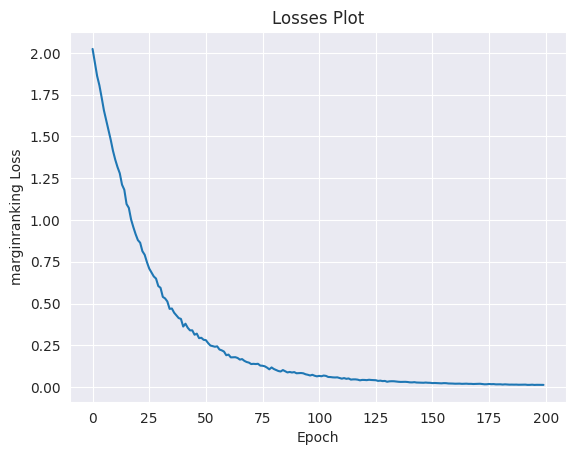

In [11]:
#try wirth TransE == has the highest of MRR score hwen trained on our ontology

NUM_EPOCHS = 200
DIMENSIONS = 16
LEARNING_RATE = 1e-3
NUM_NEGS = 50

result = pipeline(
    random_seed=0,
    model='TransE',
    training=MERGED_training,
    testing=MERGED_testing,
    training_kwargs=dict(num_epochs=NUM_EPOCHS, use_tqdm=True),
    dimensions=DIMENSIONS,
    optimizer='adam',
    optimizer_kwargs={'lr': LEARNING_RATE},
    loss='pairwisehinge',
    loss_kwargs=dict(margin=2.0),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=NUM_NEGS, filtered=True),
    regularizer='LP',
    regularizer_kwargs=dict(weight=1e-4, p=2.0),
)
print("MRR:", result.get_metric('mrr'))
result.plot_losses()

Artificial agents found: 29
HITeams found:           21
Existing hasMember triples: 45
Candidate triples (not in ontology): 588
Top 10 artificial agents by capability: ['AssistiveRobot', 'AI_SocialHealthCoach', 'AISecuritySystem', 'AlphaFoldSystem', 'AI_TrustGameTeammate', 'AI_PaleoReconstructionAssistant', 'AI_GazeAwareConversationalAgent', 'AI_LLM_MoralReasoner', 'AI_PolicySimulationAgent', 'AI_EEG_TrustCalibrationSystem', 'RobotAgent', 'GrammarlyAutocorrect', 'TeslaAutosteer', 'CodeGenerationController', 'ClinicalAIDecisionSupportTool', 'LLM_Agent', 'FormalizationAssistantAgent', 'Chatbot', 'NaoRobot', 'ArchivalFootageAISystem']


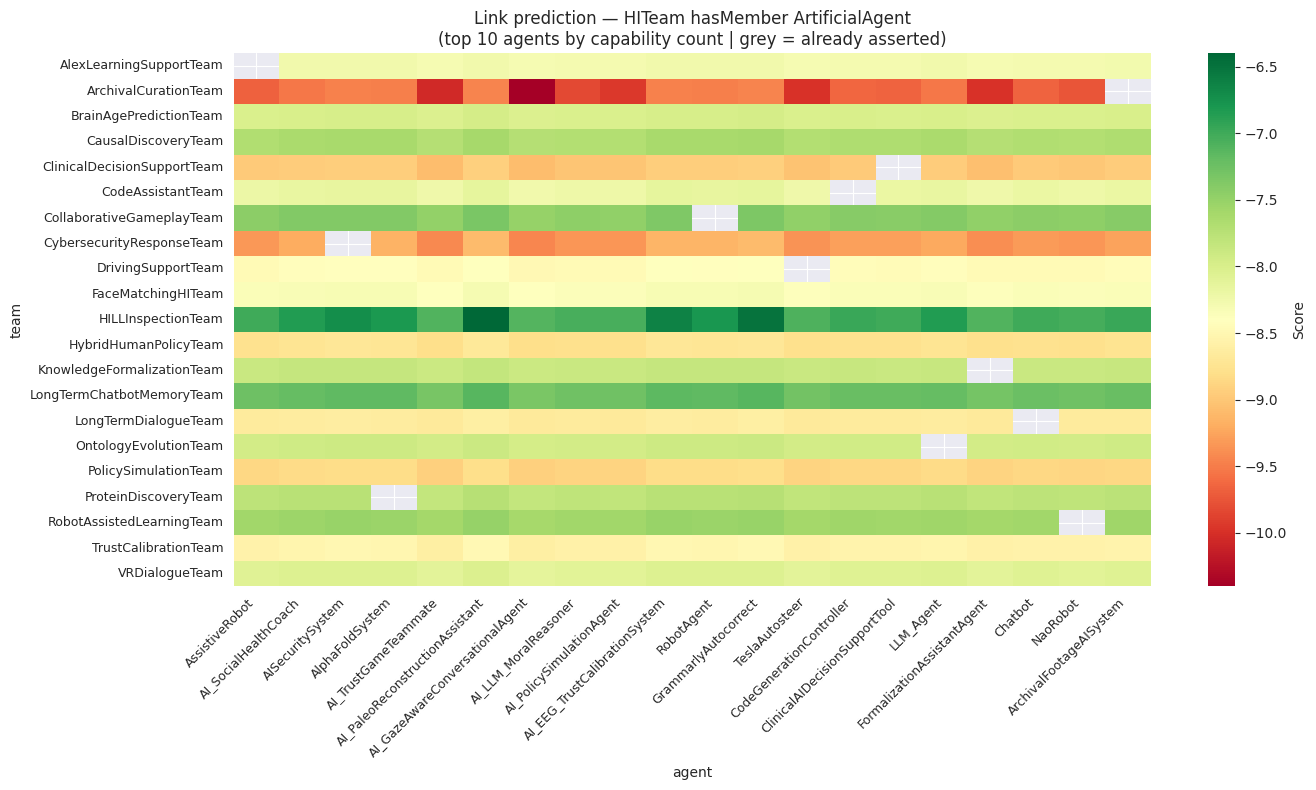

In [12]:
#link prediction task - FIND all agents and all teams - make all
from pykeen.predict import predict_triples
from scipy.special import expit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

agents_query = list(MERGED_onto.query("""
    PREFIX hi: <https://w3id.org/hi-ontology#>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

    SELECT DISTINCT ?agent
    WHERE {
        ?agent rdf:type hi:ArtificialAgent .
        FILTER(STRSTARTS(STR(?agent), 'https://w3id.org/hi-ontology#'))
    }
"""))

teams_query = list(MERGED_onto.query("""
    PREFIX hi: <https://w3id.org/hi-ontology#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

    SELECT DISTINCT ?team
    WHERE {
        ?team rdf:type hi:HITeam .
        FILTER(STRSTARTS(STR(?team), 'https://w3id.org/hi-ontology#'))
    }
"""))

agents = list(set([str(r.agent).split('#')[1] for r in agents_query]))
teams  = list(set([str(r.team).split('#')[1]  for r in teams_query]))
print(f'Artificial agents found: {len(agents)}')
print(f'HITeams found:           {len(teams)}')

# find existing tripes
existing_query = list(MERGED_onto.query("""
    PREFIX hi: <https://w3id.org/hi-ontology#>

    SELECT ?team ?agent
    WHERE {
        ?team hi:hasMember ?agent .
        FILTER(STRSTARTS(STR(?team),  'https://w3id.org/hi-ontology#'))
        FILTER(STRSTARTS(STR(?agent), 'https://w3id.org/hi-ontology#'))
    }
"""))

existing_pairs = set(
    (str(r.team).split('#')[1], str(r.agent).split('#')[1])
    for r in existing_query
)
print(f'Existing hasMember triples: {len(existing_pairs)}')

# generat all candidate triples not in ontology
candidate_triples = []
for team in teams:
    for agent in agents:
        if (team, agent) not in existing_pairs:
            candidate_triples.append([team, 'hasMember', agent])

print(f'Candidate triples (not in ontology): {len(candidate_triples)}')

#score all via the prediction
possible_combos = np.array(candidate_triples, dtype = str)
pack = predict_triples(model=result.model, triples=possible_combos, triples_factory=MERGED_HI )

#score it
processed_results = pack.process(factory=MERGED_HI ).df
probs = expit(processed_results['score'])

processed_results['prob'] = probs
processed_results['triple'] = list(zip([' '.join(x) for x in possible_combos], processed_results['prob']))

# processed_results
df = pd.DataFrame(list(zip([' '.join(x) for x in possible_combos],
                      np.squeeze(processed_results['score']),
                      np.squeeze(probs))),
             columns=['statement', 'score', 'prob']).sort_values("score", ascending=False)


#heat map
df['team']  = [x[0] for x in possible_combos]
df['agent'] = [x[2] for x in possible_combos]

heatmap_data = df.pivot_table(
    index='team',
    columns='agent',
    values='score',
    aggfunc='first'
)

# Query top 20 artificial agents by capability count
cap_query = list(MERGED_onto.query("""
    PREFIX hi: <https://w3id.org/hi-ontology#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

    SELECT ?agent (COUNT(DISTINCT ?cap) AS ?capCount)
    WHERE {
        ?agent rdf:type hi:ArtificialAgent .
        ?agent hi:hasCapability ?cap .
        FILTER(STRSTARTS(STR(?agent), 'https://w3id.org/hi-ontology#'))
    }
    GROUP BY ?agent
    ORDER BY DESC(?capCount)
    LIMIT 20
"""))

top_agents = [str(r.agent).split('#')[1] for r in cap_query]
print(f'Top 10 artificial agents by capability: {top_agents}')

# Filter heatmap to these agents
heatmap_filtered = heatmap_data[
    [a for a in top_agents if a in heatmap_data.columns]
]

import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_filtered,
    cmap='RdYlGn',
    ax=ax,
    linewidths=0,
    linecolor='none',
    cbar_kws={'label': 'Score'},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_title('Link prediction — HITeam hasMember ArtificialAgent\n(top 10 agents by capability count | grey = already asserted)')
plt.tight_layout()
plt.savefig('heatmap_team_agent.png', dpi=150, bbox_inches='tight')
plt.show()